# Flex V2 — Post-Processing Analysis

## Setup

Set `H5MU_PATH` to the path of your pipeline output file.

In [5]:
import muon as mu
import scanpy as sc

mu.set_options(pull_on_update=False)

# Path to the final pipeline output — update this to match your output directory
H5MU_PATH = "../FLEX/FLEX_V2/07_FINAL/1_multi.h5mu"

## Load the data

In [6]:
mdata = mu.read(H5MU_PATH)
mdata

MuData object with n_obs × n_vars = 4635 × 18129
  obs:	'batch_id', 'capture_id', 'cell_id'
  var:	'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
  1 modality
    gex:	4635 x 18129
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'batch_id', 'capture_id', 'cell_id'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

## Verify traceability metadata

Every cell should have `batch_id`, `capture_id`, and a globally unique `cell_id`.

In [7]:
assert "batch_id" in mdata.obs.columns
assert "capture_id" in mdata.obs.columns
assert "cell_id" in mdata.obs.columns
assert mdata.obs["cell_id"].is_unique, "cell_id must be unique!"

print(f"Total cells : {mdata.n_obs}")
print(f"Modalities  : {list(mdata.mod.keys())}")
print(f"GEX shape   : {mdata['gex'].shape}")
print()
print(mdata.obs[["batch_id", "capture_id", "cell_id"]].head())

Total cells : 4635
Modalities  : ['gex']
GEX shape   : (4635, 18129)

                   batch_id capture_id                 cell_id
AAACAAGCACACAAAT-1        1          A  1_A_AAACAAGCACACAAAT-1
AAACAAGCAGGTATAT-1        1          A  1_A_AAACAAGCAGGTATAT-1
AAACCAATCTAACCTG-1        1          A  1_A_AAACCAATCTAACCTG-1
AAACCAATCTTAAGCT-1        1          A  1_A_AAACCAATCTTAAGCT-1
AAACCAGGTGTCCAGC-1        1          A  1_A_AAACCAGGTGTCCAGC-1


## GEX quality control

Key metrics to inspect:
- `total_counts` — total UMI counts per cell
- `n_genes_by_counts` — number of detected genes per cell
- `pct_counts_mt` — percent mitochondrial counts (high values indicate damaged cells)

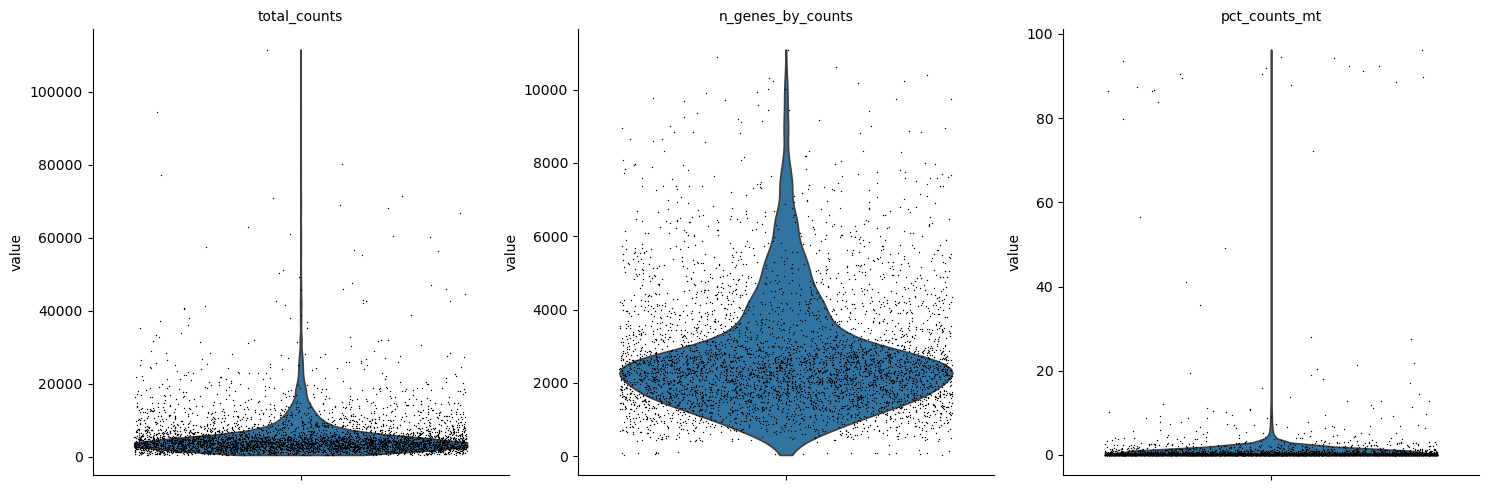

In [8]:
sc.pl.violin(
    mdata["gex"],
    ["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

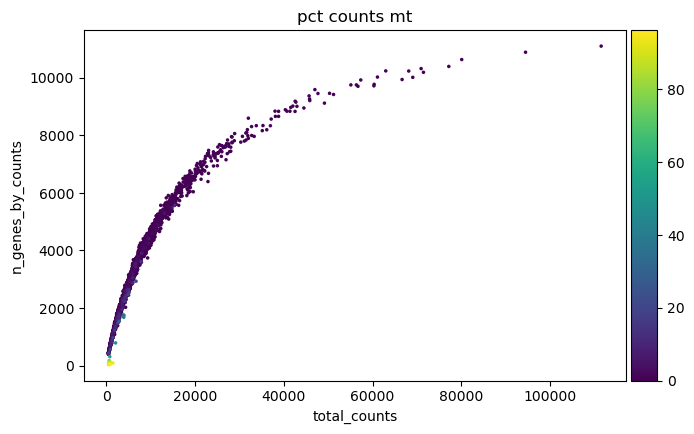

In [9]:
sc.pl.scatter(
    mdata["gex"],
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
)